# GPI 


In [1]:
# ============================================================
# 0. Imports and project path
# ============================================================
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src.pipeline import GpiPipeline
from src.preprocess_data import determine_common_period, load_regional_precipitation, load_station_raw_data
from src.utils import resolve_path
from src.visualization import (
    plot_correlation_matrix_figure,
    plot_r_vs_lag_figure,
    plot_regional_vs_local_bar,
    plot_station_paper_figure,
)

print("Imports OK.")


Imports OK.


In [2]:
# ============================================================
# 1. Configuration and study period
# ============================================================
pipeline = GpiPipeline()

STATION_IDS = ["chilgrove_house", "roman_road", "hyde_cottages_risby"]

# Common study period imposed for Table 4 / Figures 5 & 6.
# NOTE: forcing the same window for every station can substantially reduce
# the number of available observations for a station whose GW history is
# shorter or sparser (e.g. hyde_cottages_risby has only ~26 GW readings
# between 2024 and 2026, even though its full record goes back to 1967).
# A correlation computed on fewer than about thirty points is statistically
# fragile -- src.pipeline logs a warning in that case.
STUDY_PERIODS = {
    "chilgrove_house": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-04-10")),
    "roman_road": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-04-10")),
    "hyde_cottages_risby": (pd.Timestamp("2024-01-01"), pd.Timestamp("2026-04-10")),
}

print("Stations      :", STATION_IDS)
print("N candidates  :", pipeline.n_candidates)
print("L candidates  :", pipeline.l_candidates)
print("Kc            :", pipeline.kc)


Stations      : ['chilgrove_house', 'roman_road', 'hyde_cottages_risby']
N candidates  : [3, 6, 12]
L candidates  : [0, 1, 2, 3, 4, 5]
Kc            : 0.5


In [3]:

BUNDLES = {}
RESULTS = {}

for station_id in STATION_IDS:
    start, end = STUDY_PERIODS[station_id]
    bundle, result = pipeline.run_station(station_id, start, end)
    BUNDLES[station_id] = bundle
    RESULTS[station_id] = result

    print("=" * 70)
    print(f"{bundle.station_name} ({station_id})")
    print(f"Period: {start.date()} -> {end.date()}")
    print(f"  precipitation : {len(bundle.precip)} obs")
    print(f"  GW            : {len(bundle.gw)} obs")
    print(f"  PET           : {len(bundle.pet)} obs")
    print(f"  -> N* = {result.n_star} months | L* = {result.l_star} months | "
          f"r* = {result.r_star:.4f} | n_obs = {result.n_obs}")
    print()

print("Calibration complete for every Table 4 station. Results cached in RESULTS.")


2026-10-03 20:54:49 | INFO    | src.preprocess_data | [chilgrove_house] GW series loaded: 851 obs (2024-01-01 -> 2026-04-30); rainfall series: 9709 obs (1999-10-01 -> 2026-04-30)
2026-10-03 20:54:49 | WARNING | src.pet | [chilgrove_house] No geographically matched PET station is available in the supplied data (no coordinates for the PET station codes); using the national mean PET climatology as a documented fallback.
2026-10-03 20:54:50 | INFO    | src.calibration | [chilgrove_house] 18 (N, L) configurations evaluated (N in [3, 6, 12], L in [0, 1, 2, 3, 4, 5])
2026-10-03 20:54:50 | INFO    | src.preprocess_data | [roman_road] GW series loaded: 834 obs (2024-01-01 -> 2026-04-13); rainfall series: 12058 obs (1993-04-26 -> 2026-04-30)
2026-10-03 20:54:50 | WARNING | src.pet | [roman_road] No geographically matched PET station is available in the supplied data (no coordinates for the PET station codes); using the national mean PET climatology as a documented fallback.
2026-10-03 20:54:50 |

Chilgrove House (chilgrove_house)
Period: 2024-01-01 -> 2026-04-10
  precipitation : 831 obs
  GW            : 831 obs
  PET           : 831 obs
  -> N* = 6 months | L* = 0 months | r* = 0.8313 | n_obs = 652

Roman Road (roman_road)
Period: 2024-01-01 -> 2026-04-10
  precipitation : 831 obs
  GW            : 831 obs
  PET           : 831 obs
  -> N* = 12 months | L* = 0 months | r* = 0.8917 | n_obs = 472



2026-10-03 20:54:50 | INFO    | src.preprocess_data | [hyde_cottages_risby] GW series loaded: 561 obs (1967-11-23 -> 2026-04-10); rainfall series: 11047 obs (1996-02-01 -> 2026-04-30)
2026-10-03 20:54:50 | WARNING | src.pet | [hyde_cottages_risby] No geographically matched PET station is available in the supplied data (no coordinates for the PET station codes); using the national mean PET climatology as a documented fallback.
2026-10-03 20:54:50 | WARNING | src.pipeline | [hyde_cottages_risby] only 26 groundwater observations in 2024-01-01 -> 2026-04-10 (< 30); a correlation computed on such a small sample can vary substantially between runs and should not be interpreted as robust.
2026-10-03 20:54:50 | INFO    | src.calibration | [hyde_cottages_risby] 18 (N, L) configurations evaluated (N in [3, 6, 12], L in [0, 1, 2, 3, 4, 5])


Hyde Cottages Risby (hyde_cottages_risby)
Period: 2024-01-01 -> 2026-04-10
  precipitation : 831 obs
  GW            : 26 obs
  PET           : 831 obs
  -> N* = 3 months | L* = 3 months | r* = 0.9147 | n_obs = 21

Calibration complete for every Table 4 station. Results cached in RESULTS.


In [4]:
# ============================================================
# 3. Table 4 
# ============================================================
table4_rows = []
for station_id in STATION_IDS:
    r = RESULTS[station_id]
    start, end = STUDY_PERIODS[station_id]
    table4_rows.append({
        "Station": station_id,
        "N* (months)": r.n_star,
        "L* (months)": r.l_star,
        "r*": round(r.r_star, 4),
        "n_obs": r.n_obs,
        "Start": start.date(),
        "End": end.date(),
    })

table4_df = pd.DataFrame(table4_rows)
display(table4_df)


,Station,N* (months),L* (months),r*,n_obs,Start,End
0,chilgrove_house,6,0,0.8313,652,2024-01-01,2026-04-10
1,roman_road,12,0,0.8917,472,2024-01-01,2026-04-10
2,hyde_cottages_risby,3,3,0.9147,21,2024-01-01,2026-04-10


## Figure 3 


Figure saved: C:\Users\pc\Downloads\Groundwater-Potential-Index-main\figures\figure_3_chilgrove_house_matrix.png


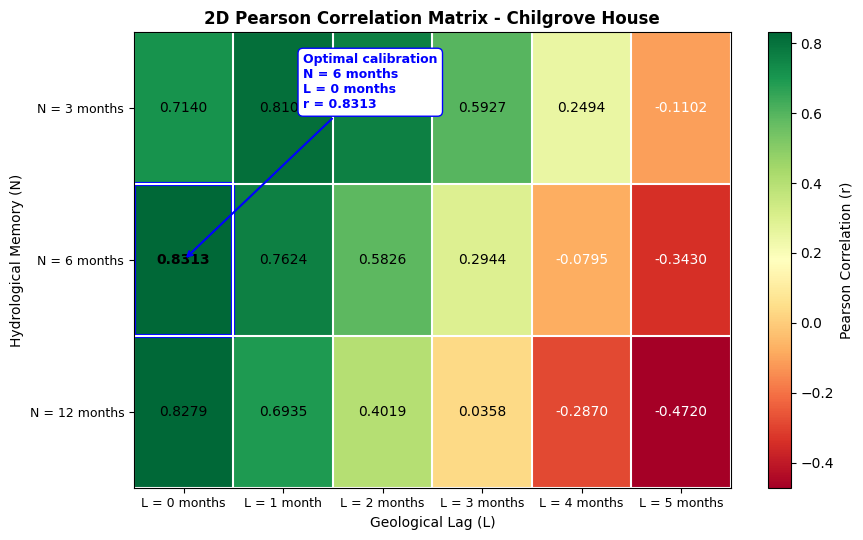

In [5]:
# ============================================================
# 4. Figure 3 — 2D correlation matrix
# ============================================================
result = RESULTS["chilgrove_house"]
bundle = BUNDLES["chilgrove_house"]

fig = plot_correlation_matrix_figure(
    result, bundle.station_name,
    save_path=REPO_ROOT / "figures" / "figure_3_chilgrove_house_matrix.png",
)
plt_show_path = REPO_ROOT / "figures" / "figure_3_chilgrove_house_matrix.png"
print("Figure saved:", plt_show_path)


## Figure 4 — Pearson's r vs. geological lag



Figure saved: C:\Users\pc\Downloads\Groundwater-Potential-Index-main\figures\figure_4_chilgrove_house_calibration.png


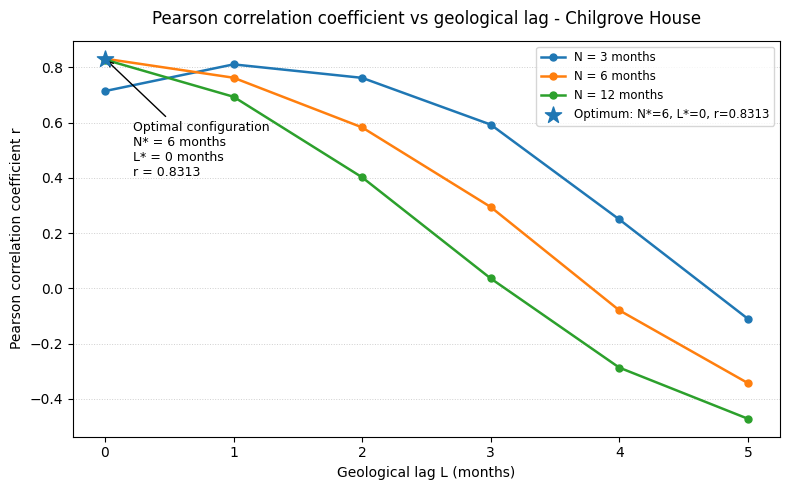

In [6]:
# ============================================================
# 5. Figure 4 — Pearson's r vs. geological lag L
# ============================================================
fig = plot_r_vs_lag_figure(
    RESULTS["chilgrove_house"], BUNDLES["chilgrove_house"].station_name,
    save_path=REPO_ROOT / "figures" / "figure_4_chilgrove_house_calibration.png",
)
print("Figure saved:", REPO_ROOT / "figures" / "figure_4_chilgrove_house_calibration.png")


## Figures 5 & 6 


C:\Users\pc\Downloads\Groundwater-Potential-Index-main\src\visualization.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Chilgrove House
N* = 6 | L* = 0 | r* (calibration) = 0.8313 | r (figure) = 0.8313 | n = 652
Roman Road
N* = 12 | L* = 0 | r* (calibration) = 0.8917 | r (figure) = 0.8917 | n = 472
Hyde Cottages Risby
N* = 3 | L* = 3 | r* (calibration) = 0.9147 | r (figure) = 0.9147 | n = 21


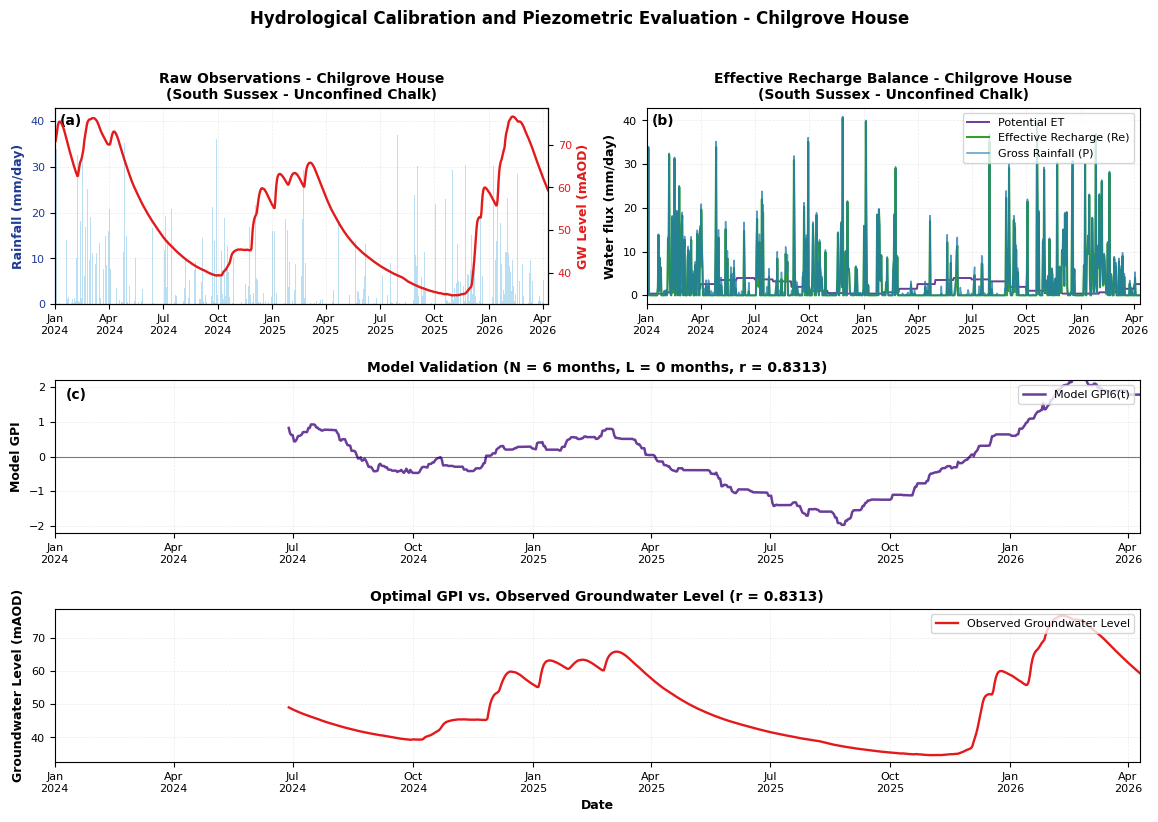

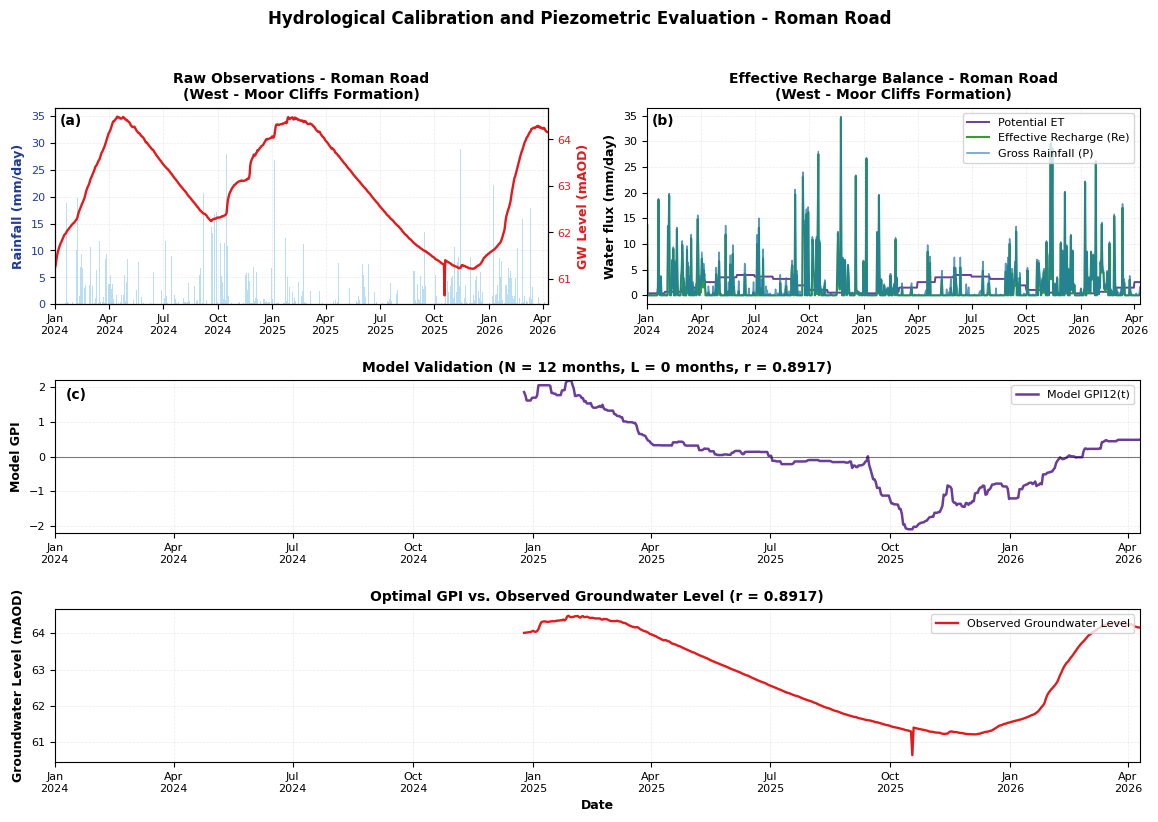

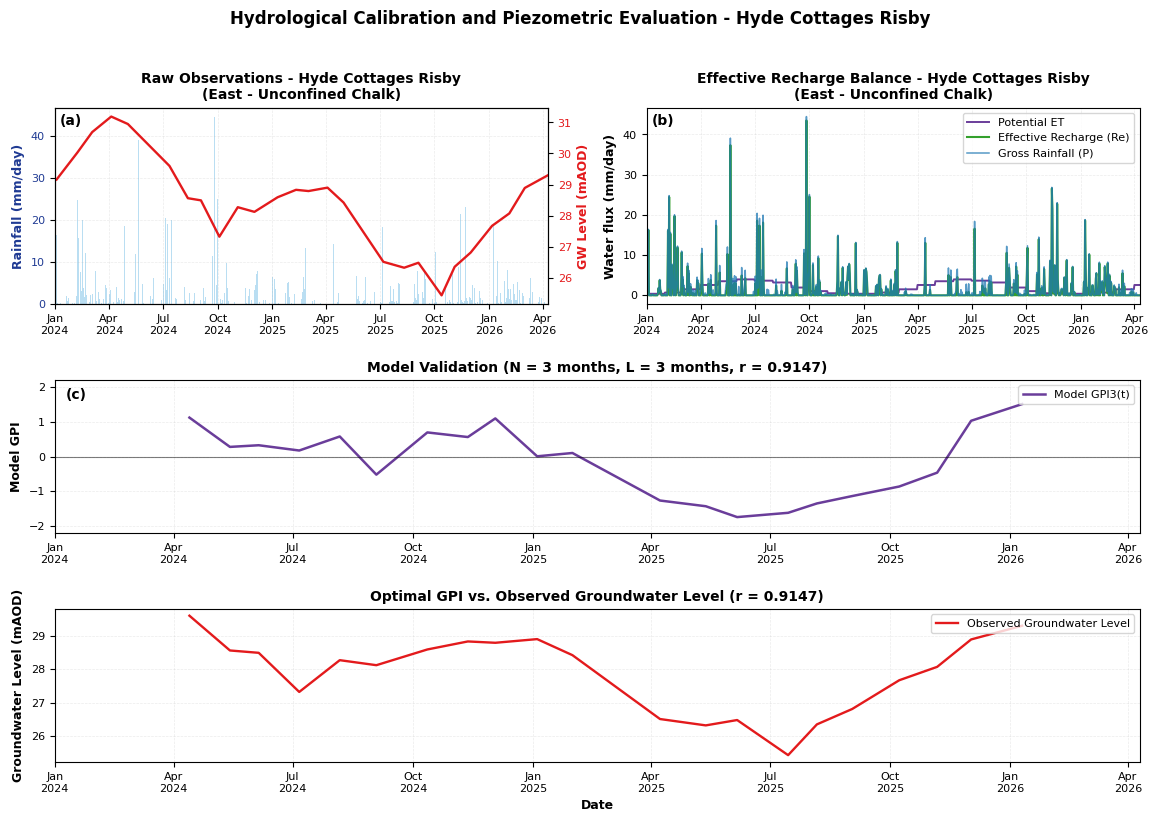

In [7]:
# ============================================================
# 6. Figures 5 & 6 — panel (a) raw observations, (b) effective recharge
#    balance, (c) modeled GPI, (d) observed groundwater level.
#    (Chilgrove House added)
# ============================================================
GEOLOGY_LABELS = {
    "chilgrove_house": "South Sussex - Unconfined Chalk",
    "roman_road": "West - Moor Cliffs Formation",
    "hyde_cottages_risby": "East - Unconfined Chalk",
}

for station_id in ["chilgrove_house", "roman_road", "hyde_cottages_risby"]:
    fig = plot_station_paper_figure(
        BUNDLES[station_id], RESULTS[station_id], GEOLOGY_LABELS[station_id],
        save_path_png=REPO_ROOT / "figures" / f"figure_{station_id}_paper_style.png",
    )
    r = RESULTS[station_id]
    r_display = r.computed_r if not np.isnan(r.computed_r) else r.r_star
    print("=" * 70)
    print(f"{BUNDLES[station_id].station_name}")
    print(f"N* = {r.n_star} | L* = {r.l_star} | r* (calibration) = {r.r_star:.4f} "
          f"| r (figure) = {r_display:.4f} | n = {len(r.comparison)}")
    print("=" * 70)

## Figure 7 

In [8]:
# ============================================================
# 7. Kemps Drift — its own observation period (not part of Table 4)
# ============================================================
KEMPS_DRIFT_ID = "kemps_drift"

kemps_station_cfg = pipeline.station_config(KEMPS_DRIFT_ID)
kemps_raw = load_station_raw_data(kemps_station_cfg)

# End of period specific to Kemps Drift, determined from its own data
# (rather than hand-set as for the Table 4 stations above).
_, kemps_end = determine_common_period([kemps_raw])

# Start aligned with the other stations (2024-01-01) to stay visually
# comparable, even though the end date differs.
kemps_start = pd.Timestamp("2023-01-01")

kemps_bundle, kemps_result = pipeline.run_station(KEMPS_DRIFT_ID, kemps_start, kemps_end)
BUNDLES[KEMPS_DRIFT_ID] = kemps_bundle
RESULTS[KEMPS_DRIFT_ID] = kemps_result

print(f"{kemps_bundle.station_name}: N* = {kemps_result.n_star} | L* = {kemps_result.l_star} "
      f"| r* = {kemps_result.r_star:.4f} | n_obs = {kemps_result.n_obs}")


2026-10-03 20:55:42 | INFO    | src.preprocess_data | [kemps_drift] GW series loaded: 366 obs (1992-07-20 -> 2025-05-29); rainfall series: 14943 obs (1985-06-02 -> 2026-04-30)
2026-10-03 20:55:42 | INFO    | src.preprocess_data | Observation period common to all stations: 1992-07-20 -> 2025-05-29
2026-10-03 20:55:43 | INFO    | src.preprocess_data | [kemps_drift] GW series loaded: 366 obs (1992-07-20 -> 2025-05-29); rainfall series: 14943 obs (1985-06-02 -> 2026-04-30)
2026-10-03 20:55:43 | WARNING | src.pet | [kemps_drift] No geographically matched PET station is available in the supplied data (no coordinates for the PET station codes); using the national mean PET climatology as a documented fallback.
2026-10-03 20:55:43 | WARNING | src.pipeline | [kemps_drift] only 29 groundwater observations in 2023-01-01 -> 2025-05-29 (< 30); a correlation computed on such a small sample can vary substantially between runs and should not be interpreted as robust.
2026-10-03 20:55:43 | INFO    | src

Kemps Drift: N* = 3 | L* = 3 | r* = 0.5169 | n_obs = 24


C:\Users\pc\Downloads\Groundwater-Potential-Index-main\src\visualization.py:204: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


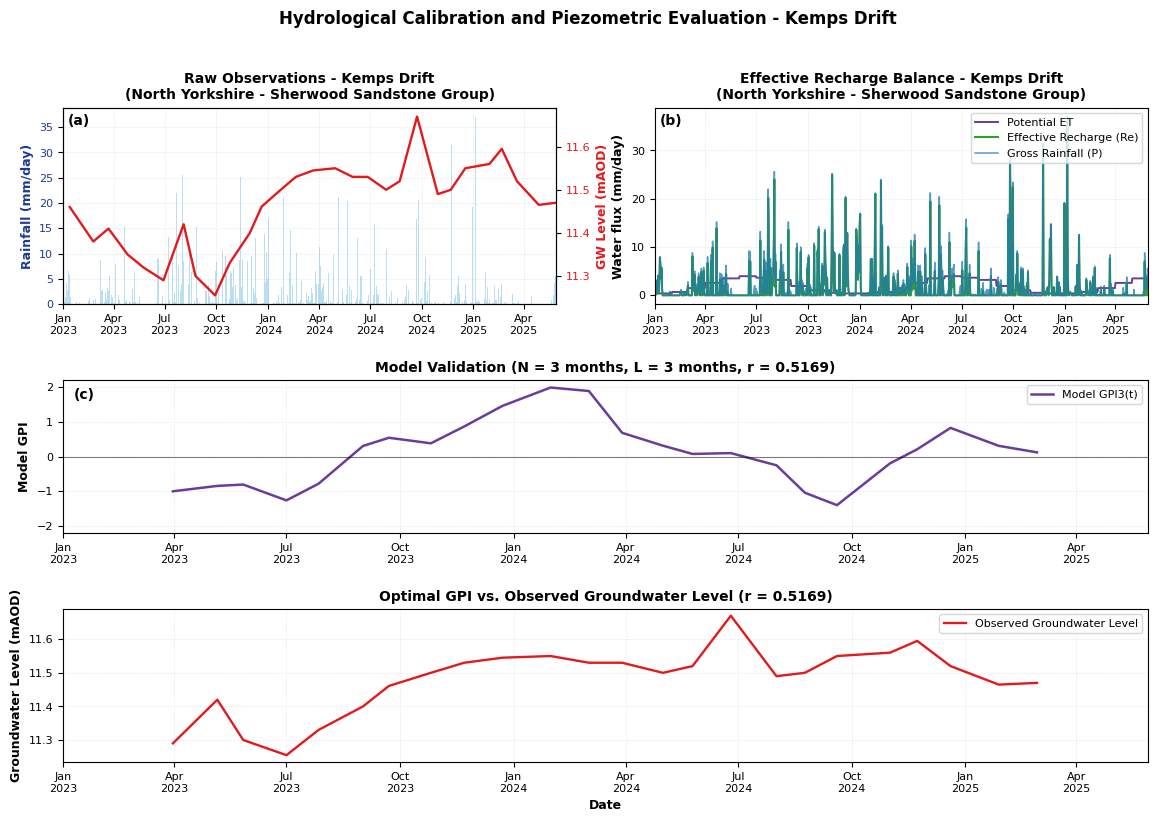

In [9]:
# Figure 7 — Kemps Drift
fig = plot_station_paper_figure(
    BUNDLES[KEMPS_DRIFT_ID], RESULTS[KEMPS_DRIFT_ID], "North Yorkshire - Sherwood Sandstone Group",
    save_path_png=REPO_ROOT / "figures" / "figure_kemps_drift_paper_style.png",
)


## Figure 8 

2026-10-03 20:56:13 | INFO    | src.calibration | [chilgrove_house] 18 (N, L) configurations evaluated (N in [3, 6, 12], L in [0, 1, 2, 3, 4, 5])
2026-10-03 20:56:13 | INFO    | src.calibration | [roman_road] 18 (N, L) configurations evaluated (N in [3, 6, 12], L in [0, 1, 2, 3, 4, 5])
2026-10-03 20:56:13 | INFO    | src.calibration | [hyde_cottages_risby] 18 (N, L) configurations evaluated (N in [3, 6, 12], L in [0, 1, 2, 3, 4, 5])
2026-10-03 20:56:13 | INFO    | src.calibration | [kemps_drift] 18 (N, L) configurations evaluated (N in [3, 6, 12], L in [0, 1, 2, 3, 4, 5])


Figure saved: C:\Users\pc\Downloads\Groundwater-Potential-Index-main\figures\figure_8_regional_vs_local.png


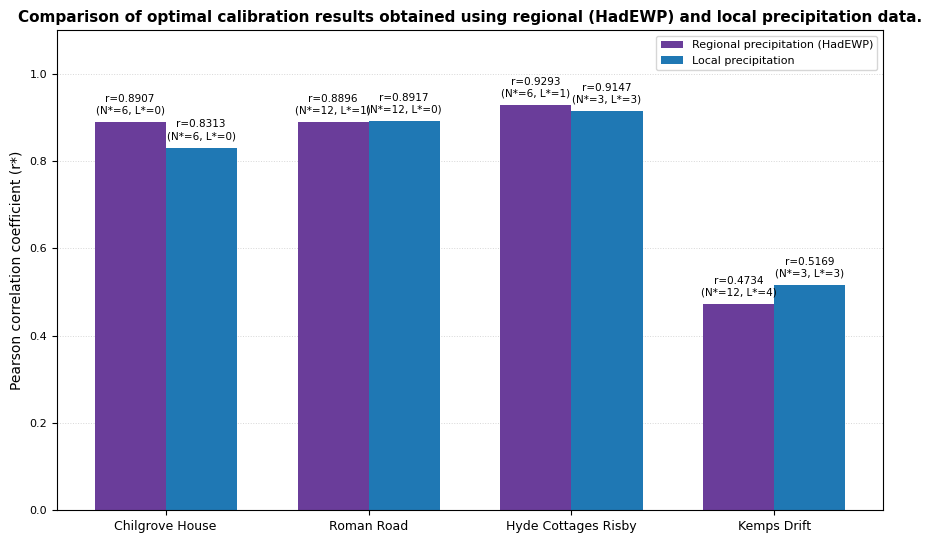

In [10]:
# ============================================================
# 8. Figure 8 — regional (HadEWP) vs. local precipitation
# ============================================================
hadewp_path = resolve_path(pipeline.stations_cfg["regional_precipitation"]["data_file"])
regional_series = load_regional_precipitation(hadewp_path)

from src.pipeline import clean_series

FIGURE8_STATIONS = STATION_IDS + [KEMPS_DRIFT_ID]
REGIONAL_RESULTS = {}
for station_id in FIGURE8_STATIONS:
    bundle = BUNDLES[station_id]
    regional_precip_raw = regional_series.reindex(bundle.precip.index)
    regional_precip = clean_series(regional_precip_raw, clip_lower_zero=True).loc[bundle.start:bundle.end]
    best = pipeline.calibrate_with_alternate_precipitation(bundle, regional_precip)
    REGIONAL_RESULTS[station_id] = {
        "r_star": float(best["pearson_r"]), "N_star": int(best["N"]), "L_star": int(best["L"]),
    }

LOCAL_RESULTS = {
    sid: {"r_star": RESULTS[sid].r_star, "N_star": RESULTS[sid].n_star, "L_star": RESULTS[sid].l_star}
    for sid in FIGURE8_STATIONS
}

labels = [BUNDLES[sid].station_name for sid in FIGURE8_STATIONS]
fig = plot_regional_vs_local_bar(
    labels, LOCAL_RESULTS, REGIONAL_RESULTS, FIGURE8_STATIONS,
    save_path=REPO_ROOT / "figures" / "figure_8_regional_vs_local.png",
)
print("Figure saved:", REPO_ROOT / "figures" / "figure_8_regional_vs_local.png")


In [11]:
from pathlib import Path

DATA_DIR = Path("data")

if not DATA_DIR.exists():
    DATA_DIR = Path("../data")

print("Dossier utilisé :", DATA_DIR.resolve())
print("\nFichiers CSV :\n")

for file in DATA_DIR.rglob("*.csv"):
    print(file)

Dossier utilisé : C:\Users\pc\Downloads\Groundwater-Potential-Index-main\data

Fichiers CSV :

..\data\station_pet_averages.csv
..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
..\data\Hyde\Rainfall\Mildenhall-rainfall-daily-Qualified.csv
..\data\Kemps\Piézométrie\9610f73b-f3af-4ede-b4e7-ec615e7ab5a2-gw-dipped-i-mAOD-qualified.csv
..\data\Kemps\Rainfall\Lower-Dunsforth-rainfall-daily-Qualified.csv
..\data\Roman road\Piézométrie\Roman-Road-level-15min-Qualified.csv
..\data\Roman road\Rainfall\Broomy-Hill-rainfall-daily-Qualified.csv


In [12]:
import pandas as pd

for file in DATA_DIR.rglob("*.csv"):
    try:
        df = pd.read_csv(file)

        print("\n" + "=" * 80)
        print("FICHIER :", file)
        print("Nombre de lignes :", len(df))
        print("Colonnes :", list(df.columns))

        if "quality" in df.columns:
            print("\nValeurs de quality :")
            print(df["quality"].value_counts(dropna=False))

    except Exception as e:
        print("Erreur :", file, e)


FICHIER : ..\data\station_pet_averages.csv
Nombre de lignes : 41508
Colonnes : ['stationReference', 'month', 'avg_daily_pet']

FICHIER : ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
Nombre de lignes : 81696
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Valeurs de quality :
quality
Good    81696
Name: count, dtype: int64

FICHIER : ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
Nombre de lignes : 9709
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Valeurs de quality :
quality
Good         6900
Unchecked    2445
Missing       180
Suspect       177
Estimated       7
Name: count, dtype: int64

FICHIER : ..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
Nombre de lignes : 561
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Valeurs de quality :
quality
Unchecked    281
Good

In [13]:
from pathlib import Path

DATA_DIR = Path("data")

if not DATA_DIR.exists():
    DATA_DIR = Path("../data")

print("Dossier :", DATA_DIR.resolve())
print("\nFichiers CSV :")

for f in DATA_DIR.rglob("*.csv"):
    print("-", f)

Dossier : C:\Users\pc\Downloads\Groundwater-Potential-Index-main\data

Fichiers CSV :
- ..\data\station_pet_averages.csv
- ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
- ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
- ..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
- ..\data\Hyde\Rainfall\Mildenhall-rainfall-daily-Qualified.csv
- ..\data\Kemps\Piézométrie\9610f73b-f3af-4ede-b4e7-ec615e7ab5a2-gw-dipped-i-mAOD-qualified.csv
- ..\data\Kemps\Rainfall\Lower-Dunsforth-rainfall-daily-Qualified.csv
- ..\data\Roman road\Piézométrie\Roman-Road-level-15min-Qualified.csv
- ..\data\Roman road\Rainfall\Broomy-Hill-rainfall-daily-Qualified.csv


In [14]:
import pandas as pd

for f in DATA_DIR.rglob("*.csv"):
    try:
        df = pd.read_csv(f)

        print("\n" + "="*80)
        print("FICHIER :", f)
        print("Dimensions :", df.shape)
        print("Colonnes :", list(df.columns))
        print("\nPremières lignes :")
        display(df.head())

    except Exception as e:
        print("Erreur :", f, e)


FICHIER : ..\data\station_pet_averages.csv
Dimensions : (41508, 3)
Colonnes : ['stationReference', 'month', 'avg_daily_pet']

Premières lignes :


,stationReference,month,avg_daily_pet
0,1029TH,1,0.458590
1,E2043,1,0.366108
2,52119,1,0.519548
3,E21136,1,0.343428
4,2067,1,0.365254



FICHIER : ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
Dimensions : (81696, 7)
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Premières lignes :


,measure,dateTime,date,value,completeness,quality,qcode
0,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T00:00:00,2024-01-01,71.184,NaN,Good,NaN
1,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T00:15:00,2024-01-01,71.182,NaN,Good,NaN
2,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T00:30:00,2024-01-01,71.178,NaN,Good,NaN
3,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T00:45:00,2024-01-01,71.152,NaN,Good,NaN
4,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T01:00:00,2024-01-01,71.176,NaN,Good,NaN



FICHIER : ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
Dimensions : (9709, 7)
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Premières lignes :


...

,measure,dateTime,date,value,completeness,quality,qcode
0,http://environment.data.gov.uk/hydrology/id/me...,1985-06-02T09:00:00,1985-06-02,0.0,Incomplete,Good,NaN
1,http://environment.data.gov.uk/hydrology/id/me...,1985-06-03T09:00:00,1985-06-03,0.0,Incomplete,Good,NaN
2,http://environment.data.gov.uk/hydrology/id/me...,1985-06-04T09:00:00,1985-06-04,0.0,Incomplete,Good,NaN
3,http://environment.data.gov.uk/hydrology/id/me...,1985-06-05T09:00:00,1985-06-05,0.0,Incomplete,Good,NaN
4,http://environment.data.gov.uk/hydrology/id/me...,1985-06-06T09:00:00,1985-06-06,0.0,Incomplete,Good,NaN



FICHIER : ..\data\Roman road\Piézométrie\Roman-Road-level-15min-Qualified.csv
Dimensions : (20003, 7)
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Premières lignes :


,measure,dateTime,date,value,completeness,quality,qcode
0,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T00:00:00,2024-01-01,61.212,NaN,Good,NaN
1,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T01:00:00,2024-01-01,61.212,NaN,Good,NaN
2,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T02:00:00,2024-01-01,61.214,NaN,Good,NaN
3,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T03:00:00,2024-01-01,61.214,NaN,Good,NaN
4,http://environment.data.gov.uk/hydrology/id/me...,2024-01-01T04:00:00,2024-01-01,61.215,NaN,Good,NaN



FICHIER : ..\data\Roman road\Rainfall\Broomy-Hill-rainfall-daily-Qualified.csv
Dimensions : (12058, 7)
Colonnes : ['measure', 'dateTime', 'date', 'value', 'completeness', 'quality', 'qcode']

Premières lignes :


,measure,dateTime,date,value,completeness,quality,qcode
0,http://environment.data.gov.uk/hydrology/id/me...,1993-04-26T09:00:00,1993-04-26,4.6,Incomplete,Good,NaN
1,http://environment.data.gov.uk/hydrology/id/me...,1993-04-27T09:00:00,1993-04-27,0.0,Incomplete,Good,NaN
2,http://environment.data.gov.uk/hydrology/id/me...,1993-04-28T09:00:00,1993-04-28,0.0,Incomplete,Good,NaN
3,http://environment.data.gov.uk/hydrology/id/me...,1993-04-29T09:00:00,1993-04-29,0.0,Incomplete,Good,NaN
4,http://environment.data.gov.uk/hydrology/id/me...,1993-04-30T09:00:00,1993-04-30,0.0,Incomplete,Good,NaN


In [15]:
for f in DATA_DIR.rglob("*.csv"):

    df = pd.read_csv(f)

    if "quality" in df.columns:

        print("\n" + "="*80)
        print("FICHIER :", f)

        print(df["quality"].value_counts(dropna=False))


FICHIER : ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
quality
Good    81696
Name: count, dtype: int64

FICHIER : ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
quality
Good         6900
Unchecked    2445
Missing       180
Suspect       177
Estimated       7
Name: count, dtype: int64

FICHIER : ..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
quality
Unchecked    281
Good         254
Suspect       26
Name: count, dtype: int64

FICHIER : ..\data\Hyde\Rainfall\Mildenhall-rainfall-daily-Qualified.csv
quality
Good         6670
Suspect      2880
Unchecked    1194
Missing       280
Estimated      23
Name: count, dtype: int64

FICHIER : ..\data\Kemps\Piézométrie\9610f73b-f3af-4ede-b4e7-ec615e7ab5a2-gw-dipped-i-mAOD-qualified.csv
quality
Good    366
Name: count, dtype: int64

FICHIER : ..\data\Kemps\Rainfall\Lower-Dunsforth-rainfall-daily-Qualified.csv
quality
Good         10785
Unchecked     2626


In [16]:
for f in DATA_DIR.rglob("*.csv"):

    df = pd.read_csv(f)

    if "value" in df.columns:

        print("\n" + "="*80)
        print("FICHIER :", f)

        print("Nombre total :", len(df))
        print("value = NaN :", df["value"].isna().sum())

        if "quality" in df.columns:
            print(
                "quality = Missing :",
                df["quality"].astype(str).str.strip().str.lower().eq("missing").sum()
            )


FICHIER : ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
Nombre total : 81696
value = NaN : 0
quality = Missing : 0

FICHIER : ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
Nombre total : 9709
value = NaN : 180
quality = Missing : 180

FICHIER : ..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
Nombre total : 561
value = NaN : 0
quality = Missing : 0

FICHIER : ..\data\Hyde\Rainfall\Mildenhall-rainfall-daily-Qualified.csv
Nombre total : 11047
value = NaN : 280
quality = Missing : 280

FICHIER : ..\data\Kemps\Piézométrie\9610f73b-f3af-4ede-b4e7-ec615e7ab5a2-gw-dipped-i-mAOD-qualified.csv
Nombre total : 366
value = NaN : 0
quality = Missing : 0

FICHIER : ..\data\Kemps\Rainfall\Lower-Dunsforth-rainfall-daily-Qualified.csv
Nombre total : 14943
value = NaN : 176
quality = Missing : 176

FICHIER : ..\data\Roman road\Piézométrie\Roman-Road-level-15min-Qualified.csv
Nombre total : 20003
value = NaN 

In [17]:
for f in DATA_DIR.rglob("*.csv"):

    df = pd.read_csv(f)

    if "date" not in df.columns:
        continue

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    print("\n" + "="*80)
    print("FICHIER :", f)

    print("Première date :", df["date"].min())
    print("Dernière date :", df["date"].max())
    print("Dates invalides :", df["date"].isna().sum())


FICHIER : ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
Première date : 2024-01-01 00:00:00
Dernière date : 2026-04-30 00:00:00
Dates invalides : 0

FICHIER : ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
Première date : 1999-10-01 00:00:00
Dernière date : 2026-04-30 00:00:00
Dates invalides : 0

FICHIER : ..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
Première date : 1967-11-23 00:00:00
Dernière date : 2026-04-10 00:00:00
Dates invalides : 0

FICHIER : ..\data\Hyde\Rainfall\Mildenhall-rainfall-daily-Qualified.csv
Première date : 1996-02-01 00:00:00
Dernière date : 2026-04-30 00:00:00
Dates invalides : 0

FICHIER : ..\data\Kemps\Piézométrie\9610f73b-f3af-4ede-b4e7-ec615e7ab5a2-gw-dipped-i-mAOD-qualified.csv
Première date : 1992-07-20 00:00:00
Dernière date : 2025-05-29 00:00:00
Dates invalides : 0

FICHIER : ..\data\Kemps\Rainfall\Lower-Dunsforth-rainfall-daily-Qualified.csv
Première date

In [18]:
for f in DATA_DIR.rglob("*.csv"):

    df = pd.read_csv(f)

    required = {"date", "quality"}

    if not required.issubset(df.columns):
        continue

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    missing = (
        df["quality"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("missing")
    )

    missing_2023 = missing & (df["date"] >= "2023-01-01")

    print("\n" + "="*80)
    print("FICHIER :", f)
    print("Total Missing :", missing.sum())
    print("Missing depuis 2023-01-01 :", missing_2023.sum())


FICHIER : ..\data\Chilgrove\Piézométrie\Chilgrove-House-level-15min-Qualified.csv
Total Missing : 0
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Chilgrove\Rainfall\Chilgrove-House-rainfall-daily-Qualified.csv
Total Missing : 180
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Hyde\Piézométrie\ea15dfcd-00b7-41d9-91b6-c4fc325d9cb8-gw-dipped-i-mAOD-qualified.csv
Total Missing : 0
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Hyde\Rainfall\Mildenhall-rainfall-daily-Qualified.csv
Total Missing : 280
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Kemps\Piézométrie\9610f73b-f3af-4ede-b4e7-ec615e7ab5a2-gw-dipped-i-mAOD-qualified.csv
Total Missing : 0
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Kemps\Rainfall\Lower-Dunsforth-rainfall-daily-Qualified.csv
Total Missing : 176
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Roman road\Piézométrie\Roman-Road-level-15min-Qualified.csv
Total Missing : 0
Missing depuis 2023-01-01 : 0

FICHIER : ..\data\Roman road\Rainfall\Broomy-Hill-r